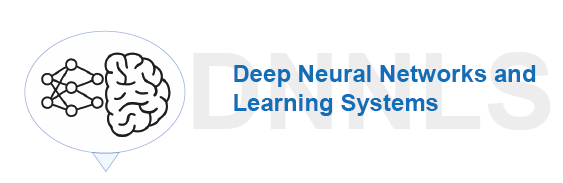

# Final assessment - Main Notebook
---

**Introduction:**

In this notebook you will find a baseline, functional architecture for your assessment task.

In [5]:
import gc
import os
import random
import re
import re
import textwrap
from typing import Dict, Any, List, Optional, Tuple

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
# @title Importing the necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.transforms.functional as FT
from bs4 import BeautifulSoup
from datasets.fingerprint import random
from google.colab import drive
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import BertTokenizer
from google.colab import drive

from src.model import (EncoderLSTM, DecoderLSTM, Seq2SeqLSTM,
                        Backbone, VisualEncoder, VisualDecoder, VisualAutoencoder,
                        Attention, SequencePredictor,
                        ResNetVisualEncoder, ModifiedSequencePredictor)

from src.utils import (save_checkpoint_to_drive, load_checkpoint_from_drive,
                        parse_gdi_text, show_image, SequencePredictionDataset,
                        TextTaskDataset, AutoEncoderTaskDataset, init_weights,
                        generate, validation)

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# **Chapter 1: The data preparation**


---



First we need to activate our google drive so that we can save out data permanently.

## 1.1 Loading and saving data

Now we load dataset from HuggingFace:

In [4]:
# @title Loading the dataset
from datasets import load_dataset

train_dataset = load_dataset("daniel3303/StoryReasoning", split="train")
test_dataset = load_dataset("daniel3303/StoryReasoning", split="test")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/327M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/331M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/115M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3552 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/626 [00:00<?, ? examples/s]

In [6]:
# @title For the Sequence prediction task
"""
This cell sets up the data pipeline for the main sequence prediction task.
1. Initializes the BERT tokenizer.
2. Creates `SequencePredictionDataset` instances for training and testing.
3. Splits the training data into `train_subset` and `val_subset`.
4. Creates `DataLoader` objects (`train_dataloader`, `val_dataloader`, `test_dataloader`) to batch and shuffle the data.
"""

tokenizer = BertTokenizer.from_pretrained("google-bert/bert-base-uncased",  padding=True, truncation=True)
sp_train_dataset = SequencePredictionDataset(train_dataset, tokenizer) # Instantiate the train dataset
sp_test_dataset = SequencePredictionDataset(test_dataset, tokenizer) # Instantiate the test dataset

# Let's do things properly, we will also have a validation split
# Split the training dataset into training and validation sets
train_size = int(0.8 * len(sp_train_dataset))
val_size = len(sp_train_dataset) - train_size
train_subset, val_subset = random_split(sp_train_dataset, [train_size, val_size])

# Instantiate the dataloaders
train_dataloader = DataLoader(train_subset, batch_size=8, shuffle=True)
# We will use the validation set to visualize the progress.
val_dataloader = DataLoader(val_subset, batch_size=4, shuffle=True)
test_dataloader = DataLoader(sp_test_dataset, batch_size=4, shuffle=False)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [7]:
# @title For the text task
"""
Sets up the data pipeline for the auxiliary text autoencoding task.
Creates the `TextTaskDataset` and its corresponding `DataLoader`.
"""

tokenizer = BertTokenizer.from_pretrained("google-bert/bert-base-uncased",  padding=True, truncation=True)
text_dataset = TextTaskDataset(train_dataset)
text_dataloader = DataLoader(text_dataset, batch_size=4, shuffle=True)

In [8]:
# @title For the image autoencoder task
"""
Sets up the data pipeline for the auxiliary visual autoencoding task.
Creates the `AutoEncoderTaskDataset` and its `DataLoader`.
"""

autoencoder_dataset = AutoEncoderTaskDataset(train_dataset)
autoencoder_dataloader = DataLoader(autoencoder_dataset, batch_size=4, shuffle=True)

Description:  torch.Size([4, 120])
torch.Size([8, 4, 3, 60, 125])
torch.Size([8, 4, 120])


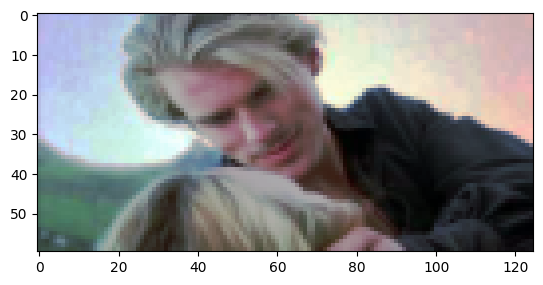

In [9]:
"""
A sanity check cell to verify the data pipeline.
It grabs a single batch from the training dataset and prints the shapes of the returned tensors (images, descriptions, etc.) to ensure everything is loaded correctly.
"""

frames, descriptions, image_target, text_target, roi1, roi2, roi_valid, roi_frame, ent_id = sp_train_dataset[np.random.randint(0,400)]

print("Description: ", descriptions.shape)
figure, ax = plt.subplots(1,1)
show_image(ax, image_target)

# Do some tests on the batches (try with batch size small)
frames, descriptions, image_target, text_target, roi1, roi2, roi_valid, roi_frame, ent_id = next(iter(train_dataloader))
print(frames.shape)
print(descriptions.shape)

In [10]:
# @title Variables and initial setup
"""
Global setup:
- Sets the computation device (CUDA/CPU).
- Defines hyperparameters: `N_EPOCHS`, `emb_dim`, `latent_dim`, etc.
"""

torch.cuda.empty_cache()
gc.collect()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N_EPOCHS = 10
emb_dim = 16
latent_dim = 16
num_layers = 1
dropout = True

In [11]:
# @title Initializing the NLP models
"""
1. Instantiates the `EncoderLSTM`, `DecoderLSTM`, and `Seq2SeqLSTM`.
2. Loads pre-trained weights from Google Drive (`text_autoencoder.pth`).
3. Freezes the text autoencoder parameters to keep them fixed during the main training phase.
"""

encoder = EncoderLSTM(tokenizer.vocab_size, emb_dim, latent_dim, num_layers, dropout).to(device)
decoder = DecoderLSTM(tokenizer.vocab_size, emb_dim, latent_dim, num_layers, dropout).to(device)
text_autoencoder = Seq2SeqLSTM(encoder, decoder).to(device)
text_autoencoder, _, _, _ = load_checkpoint_from_drive(text_autoencoder, None, filename='text_autoencoder.pth')

total_params = sum(p.numel() for p in text_autoencoder.parameters())
print(f"Total parameters (Not trainable): {total_params}")
# Deactivating training from this model for efficiency (although not ideal)
for param in text_autoencoder.parameters():
        param.requires_grad = False

Checkpoint loaded from: /content/gdrive/MyDrive/DL_Checkpoints/text_autoencoder.pth (epoch 15)
Total parameters (Not trainable): 1499930


In [12]:
# @title Initializing visual models
"""
1. Instantiates the `VisualAutoencoder`.
2. Applies the custom weight initialization.
"""

visual_autoencoder = VisualAutoencoder(latent_dim=16)
visual_autoencoder.apply(init_weights)

total_params = sum(p.numel() for p in visual_autoencoder.parameters() if p.requires_grad)
print(f"Total trainable parameters in visual autoencoder: {total_params}")

Total trainable parameters in visual autoencoder: 503539


In [13]:
# @title Initialize the main architecture
"""
Instantiates the full `SequencePredictor` model, wiring together the visual encoder, text encoder, and the sequence modeling components.
Prints the total number of parameters.
"""

# We put all the sizes the same, not ideal as well
sequence_predictor = SequencePredictor(visual_autoencoder, text_autoencoder, latent_dim, latent_dim)
sequence_predictor.to(device)

# # Print number of trainable parameters
total_params = sum(p.numel() for p in sequence_predictor.parameters() if p.requires_grad)
print(f"Total trainable parameters in the whole model: {total_params}")

# Print model size
total_params = sum(p.numel() for p in sequence_predictor.parameters())
print(f"Total parameters: {total_params}")

Total trainable parameters in the whole model: 507028
Total parameters: 2006958


## 3.2 Training loops

In [ ]:
# @title Training loop
from src.train import train_model

losses = train_model(
    model=sequence_predictor,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    tokenizer=tokenizer,
    device=device,
    n_epochs=10,
    log_file='/content/gdrive/MyDrive/DL_Checkpoints/baseline_training_log.txt',
    checkpoint_name='baseline_checkpoint.pth'
)

Experiment 1 trainable parameters: 5037940
Epoch [1/10] Loss: 4.2062  (im=0.226, ctx=0.027, txt=6.123, reid=0.000, g_mse=0.000, nce=0.000, entpool=0.000)


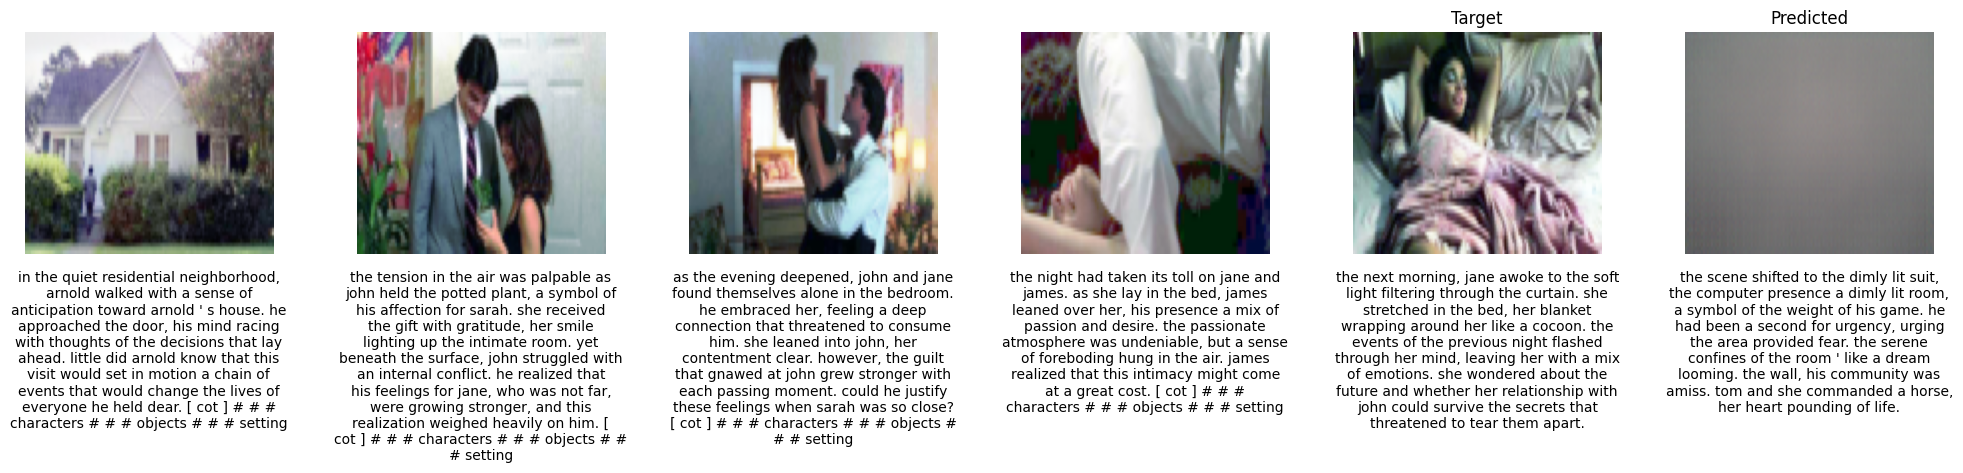

Checkpoint saved to Google Drive: /content/gdrive/MyDrive/DL_Checkpoints/experiment1_checkpoint.pth at epoch 0
Epoch [2/10] Loss: 4.1205  (im=0.227, ctx=0.024, txt=3.227, reid=0.001, g_mse=0.389, nce=0.000, entpool=0.000)


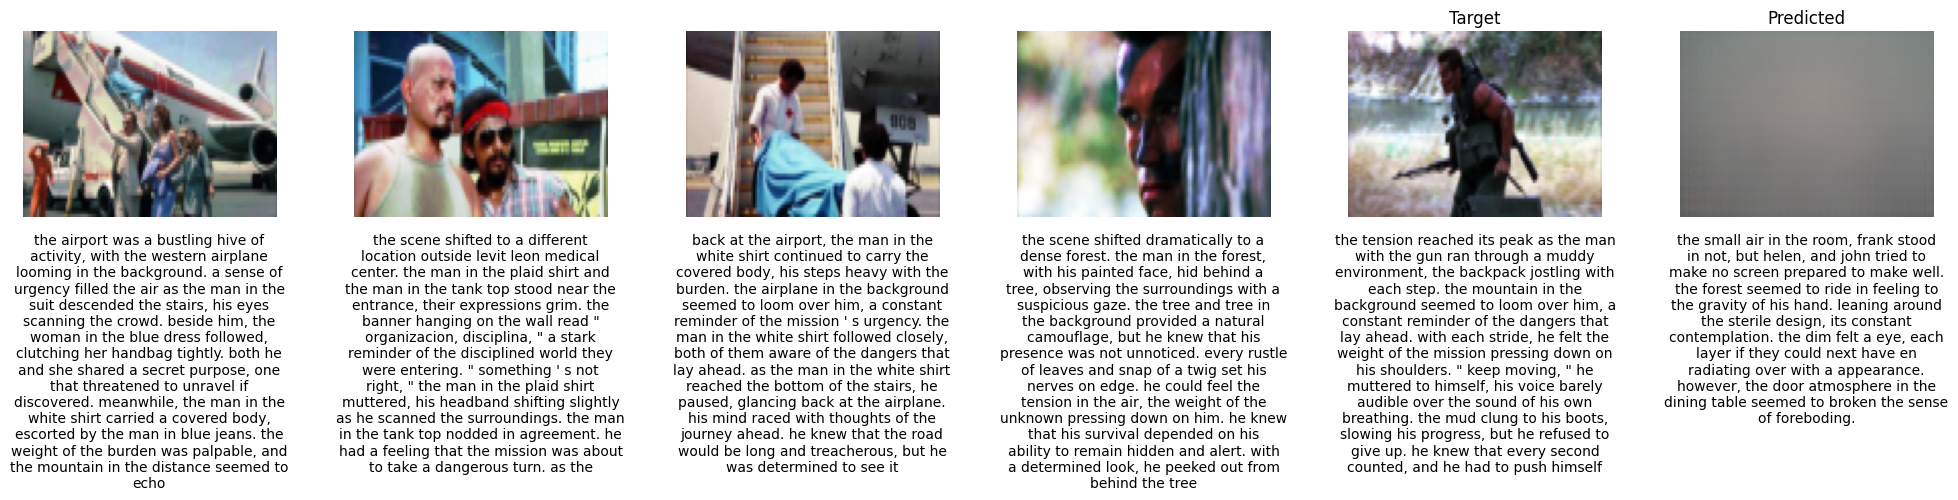

Checkpoint saved to Google Drive: /content/gdrive/MyDrive/DL_Checkpoints/experiment1_checkpoint.pth at epoch 1
Epoch [3/10] Loss: 4.1251  (im=0.211, ctx=0.017, txt=3.839, reid=0.001, g_mse=0.188, nce=0.000, entpool=0.000)


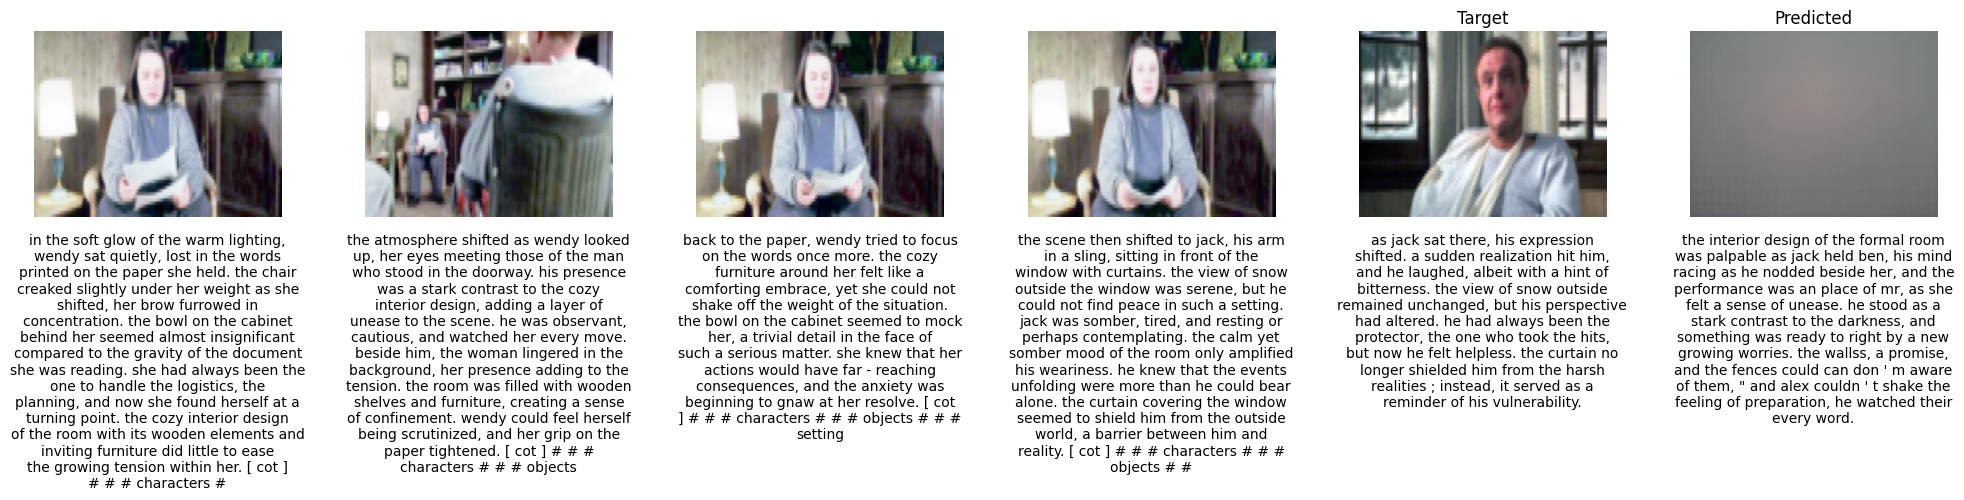

Checkpoint saved to Google Drive: /content/gdrive/MyDrive/DL_Checkpoints/experiment1_checkpoint.pth at epoch 2
Epoch [4/10] Loss: 4.1164  (im=0.218, ctx=0.020, txt=4.722, reid=0.001, g_mse=0.173, nce=0.000, entpool=0.000)


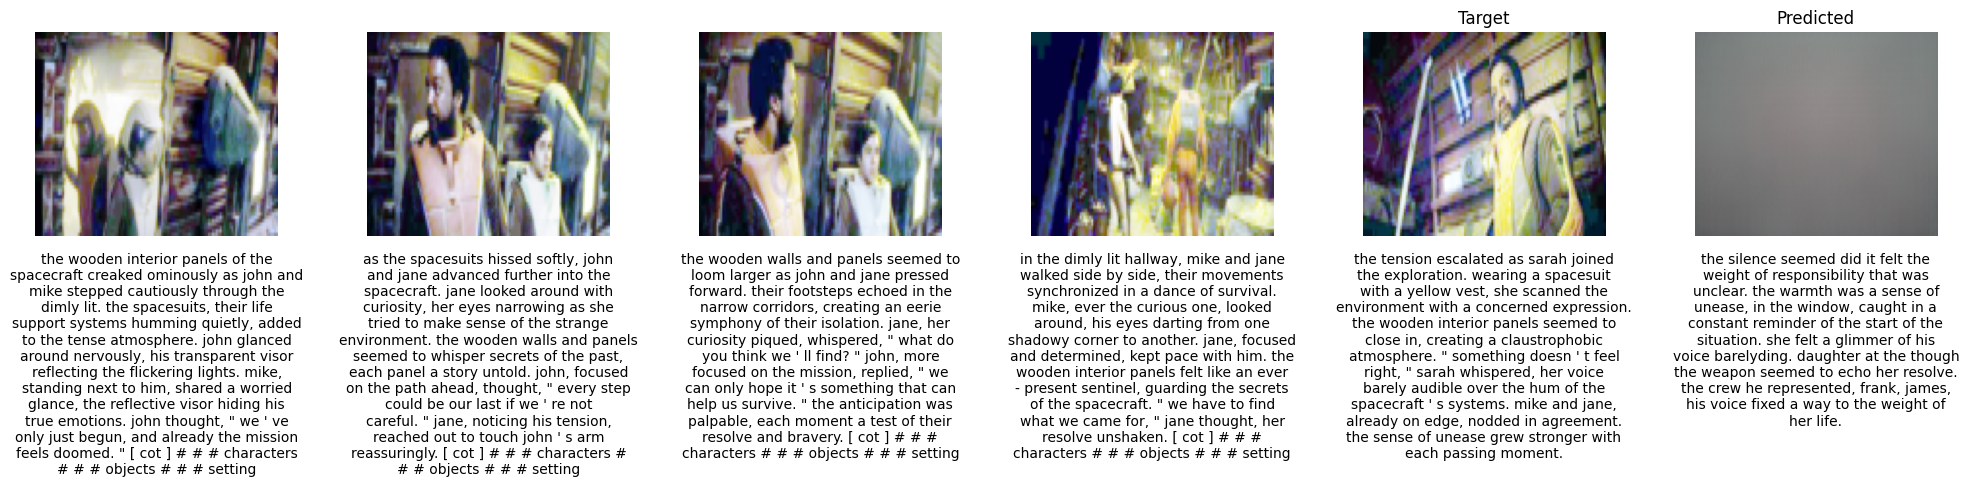

Checkpoint saved to Google Drive: /content/gdrive/MyDrive/DL_Checkpoints/experiment1_checkpoint.pth at epoch 3
Epoch [5/10] Loss: 4.1093  (im=0.225, ctx=0.025, txt=3.580, reid=0.000, g_mse=0.000, nce=0.000, entpool=0.000)


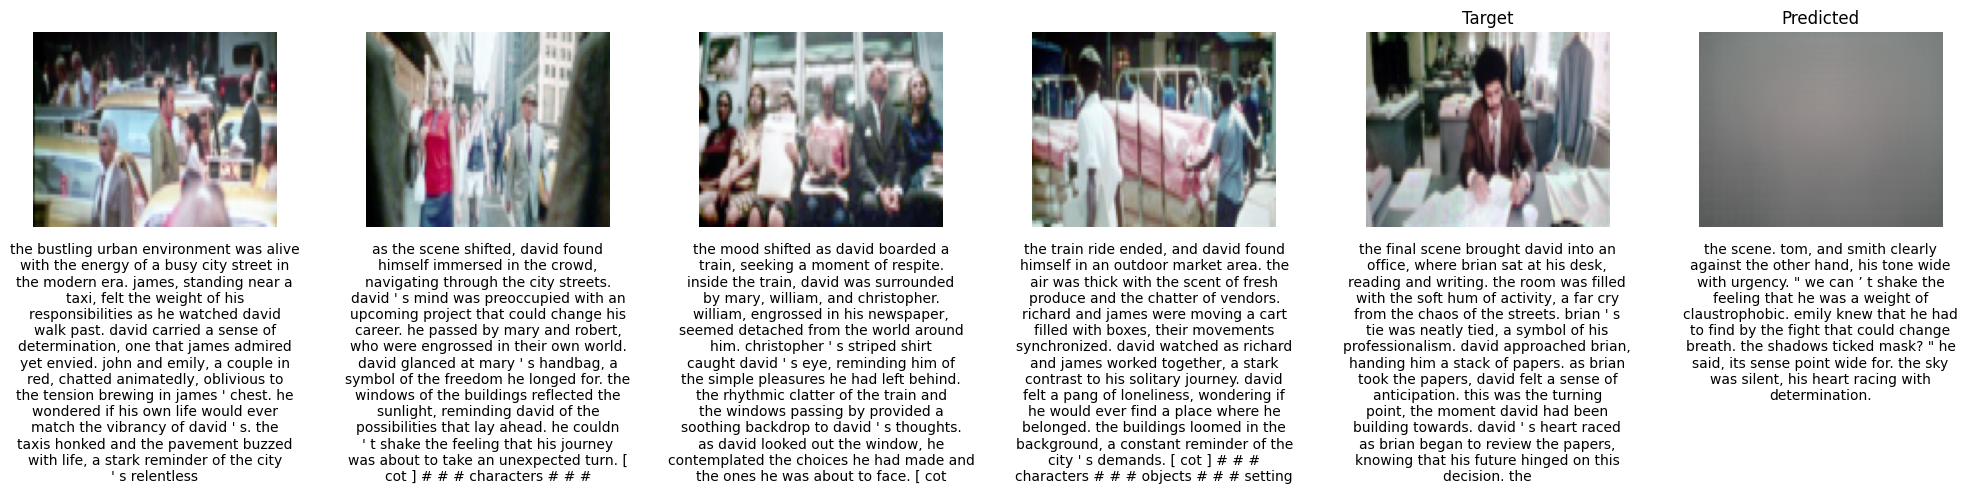

Checkpoint saved to Google Drive: /content/gdrive/MyDrive/DL_Checkpoints/experiment1_checkpoint.pth at epoch 4
Epoch [6/10] Loss: 4.0996  (im=0.243, ctx=0.018, txt=2.767, reid=0.000, g_mse=0.197, nce=0.000, entpool=0.000)


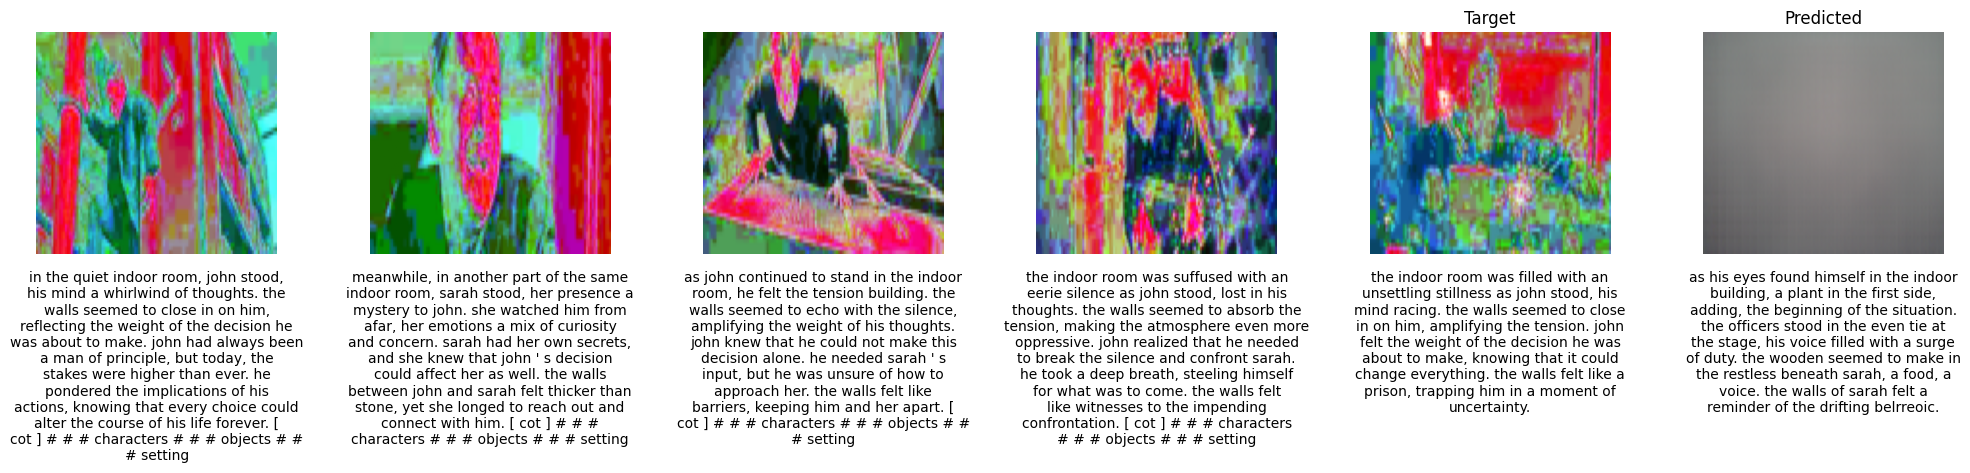

Checkpoint saved to Google Drive: /content/gdrive/MyDrive/DL_Checkpoints/experiment1_checkpoint.pth at epoch 5
Epoch [7/10] Loss: 4.0999  (im=0.232, ctx=0.019, txt=3.755, reid=0.001, g_mse=0.102, nce=0.000, entpool=0.000)


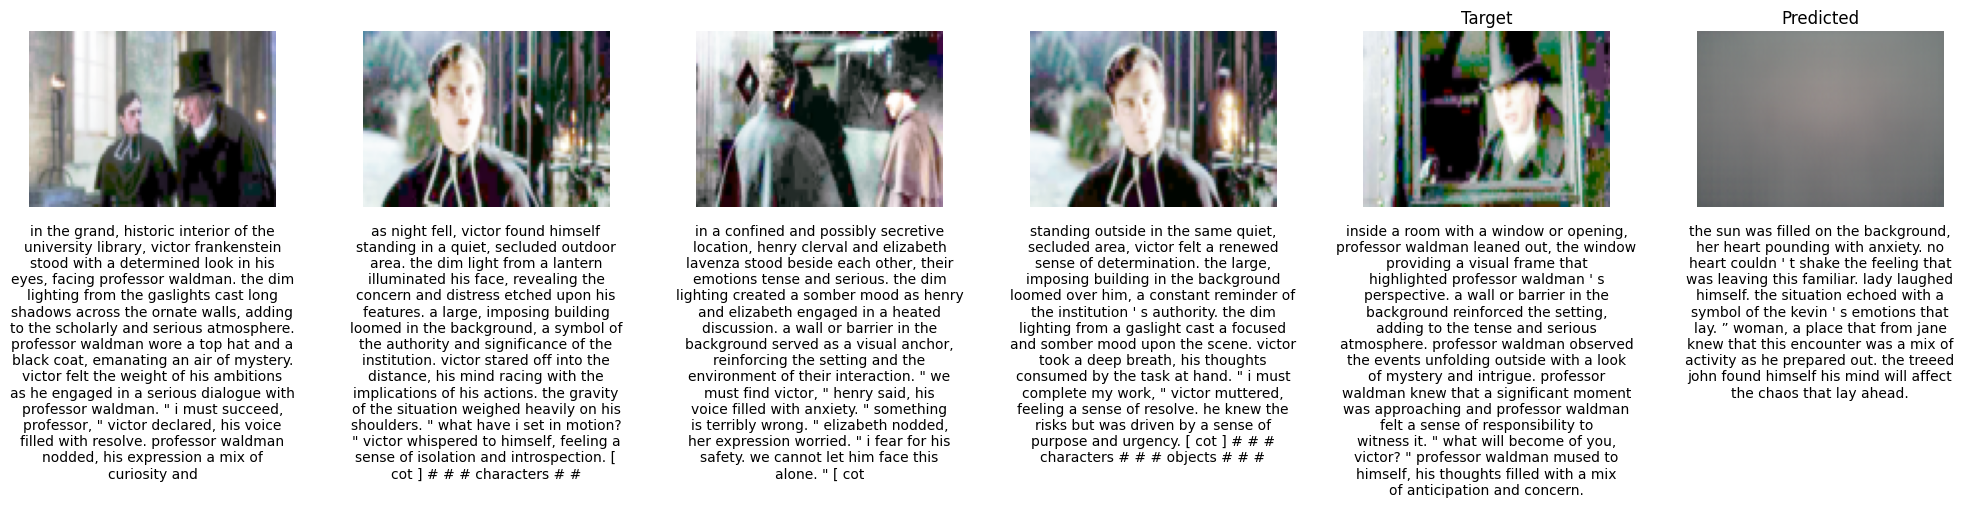

Checkpoint saved to Google Drive: /content/gdrive/MyDrive/DL_Checkpoints/experiment1_checkpoint.pth at epoch 6
Epoch [8/10] Loss: 4.0965  (im=0.258, ctx=0.021, txt=3.483, reid=0.000, g_mse=0.000, nce=0.000, entpool=0.000)


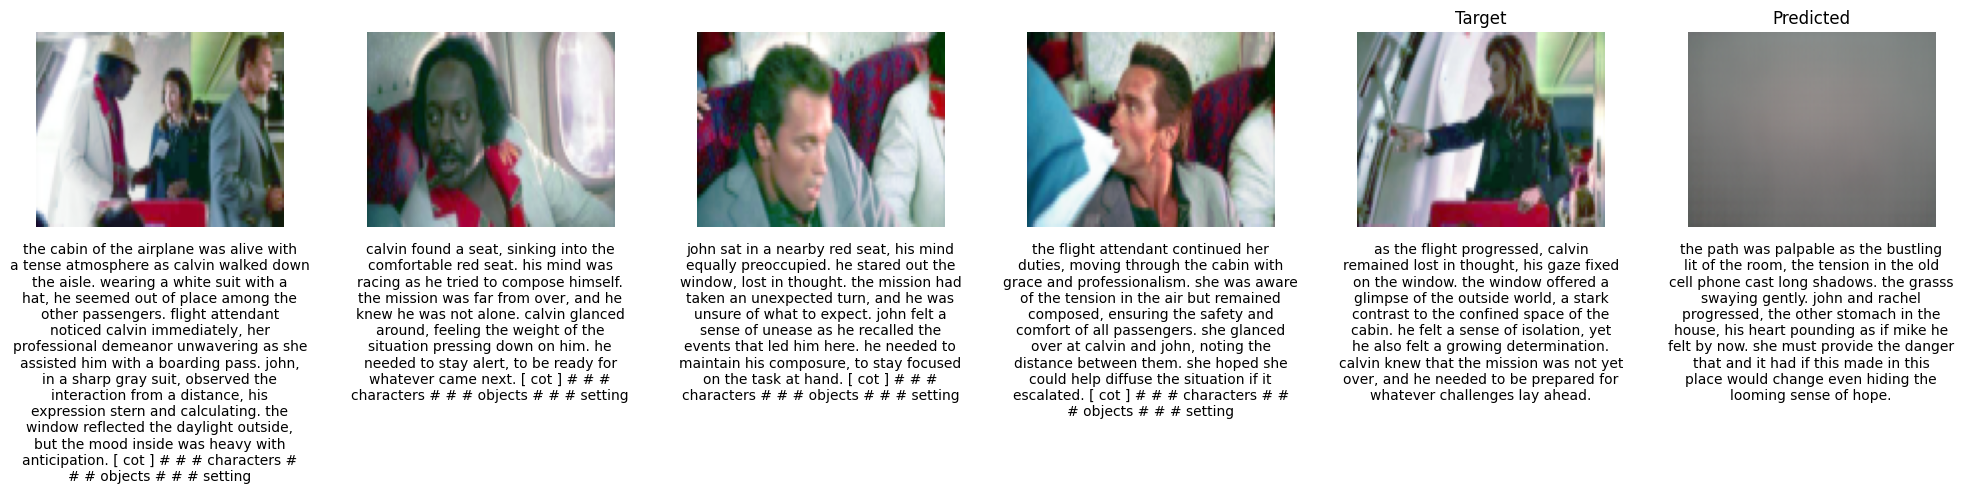

Checkpoint saved to Google Drive: /content/gdrive/MyDrive/DL_Checkpoints/experiment1_checkpoint.pth at epoch 7
Epoch [9/10] Loss: 4.0996  (im=0.196, ctx=0.032, txt=4.314, reid=0.000, g_mse=0.000, nce=0.000, entpool=0.000)


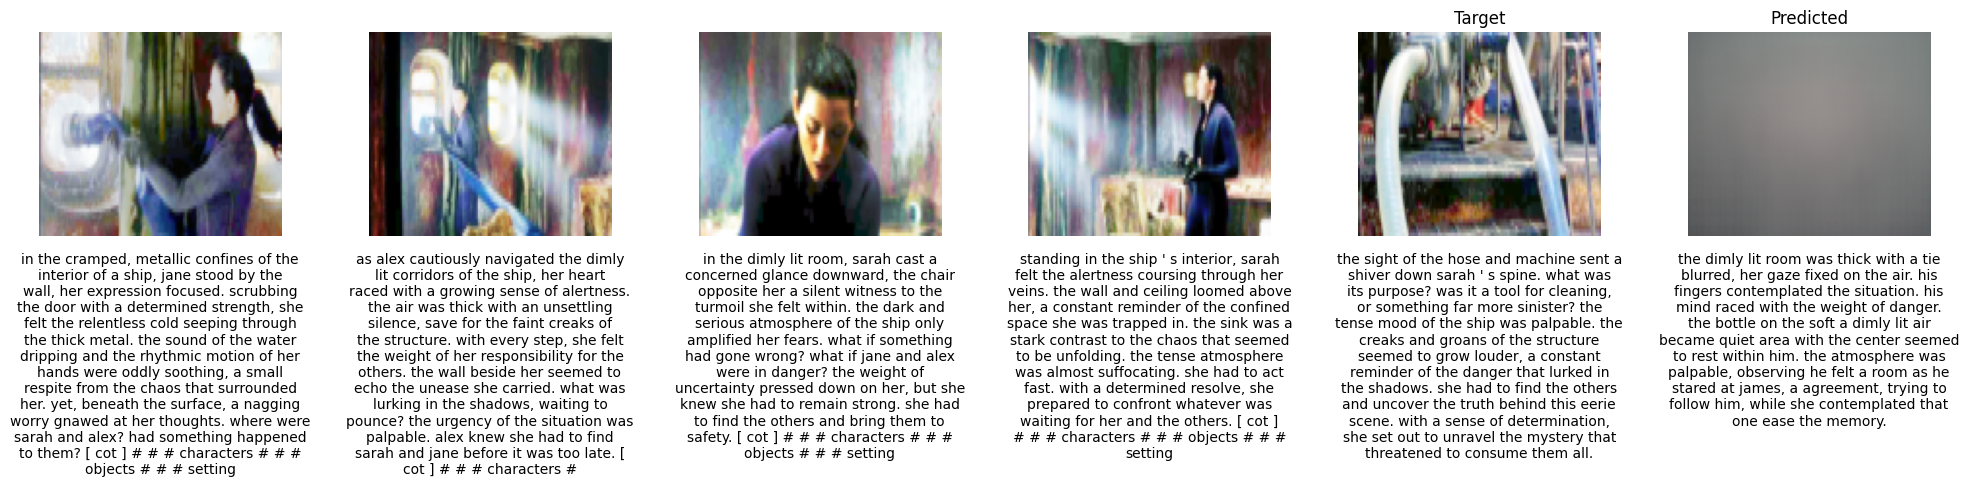

Checkpoint saved to Google Drive: /content/gdrive/MyDrive/DL_Checkpoints/experiment1_checkpoint.pth at epoch 8
Epoch [10/10] Loss: 4.0962  (im=0.270, ctx=0.052, txt=4.789, reid=0.000, g_mse=0.000, nce=0.000, entpool=0.000)


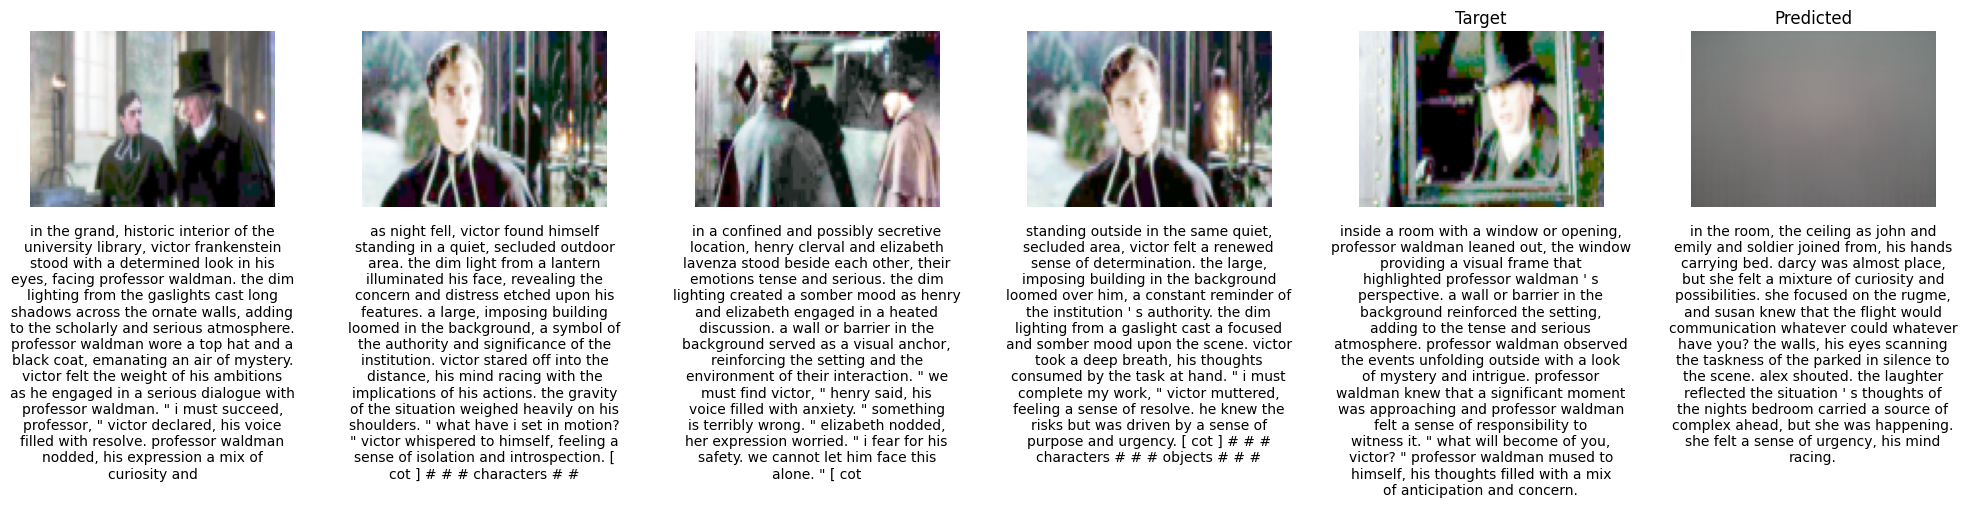

Checkpoint saved to Google Drive: /content/gdrive/MyDrive/DL_Checkpoints/experiment1_checkpoint.pth at epoch 9
Training log saved to /content/gdrive/MyDrive/DL_Checkpoints/experiment1_training_log.txt


In [15]:
# =============================================================================
# Experiment 1: ResNet Visual Encoder + GRU (baseline sequence model)
# =============================================================================
from src.train import train_model


resnet_encoder = ResNetVisualEncoder(latent_dim=16).to(device)

exp1_model = ModifiedSequencePredictor(resnet_encoder, text_autoencoder, latent_dim, latent_dim)
exp1_model.to(device)

total_params = sum(p.numel() for p in exp1_model.parameters() if p.requires_grad)
print(f"Experiment 1 trainable parameters: {total_params}")

exp1_losses = train_model(
    model=exp1_model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    tokenizer=tokenizer,
    device=device,
    n_epochs=10,
    log_file='/content/gdrive/MyDrive/DL_Checkpoints/experiment1_training_log.txt',
    checkpoint_name='experiment1_checkpoint.pth'
)

In [ ]:
# @title Example text reconstruction task
"""
EXPLANATION:
A standalone training loop for the text autoencoder.
This is used if you want to pre-train or fine-tune the text module separately before the main task.
"""

# Don't forget to unfreeze the model!
# We need to unfreeze the parameters so we can calculate gradients
for param in text_autoencoder.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(text_autoencoder.parameters(), lr=0.001)

loss_fn = nn.CrossEntropyLoss(ignore_index=tokenizer.convert_tokens_to_ids(tokenizer.pad_token))
N_EPOCHS = 5

for epoch in range(N_EPOCHS):
    text_autoencoder.train()
    epoch_loss = 0
    for description in text_dataloader:
        # Move the "sentences" to device
        input_ids = tokenizer(description, return_tensors="pt",  padding=True, truncation=True).input_ids
        input_ids = input_ids.to(device)

        # zero the grad, then forward pass
        optimizer.zero_grad()
        outputs = text_autoencoder(input_ids, input_ids)
        # compute the loss: compare 3D logits to 2D targets
        loss = loss_fn(outputs.reshape(-1, tokenizer.vocab_size), input_ids[:, 1:].reshape(-1))
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{N_EPOCHS}; Avg loss {epoch_loss/len(text_dataloader)}; Latest loss {loss.item()}")
    torch.save(text_autoencoder.state_dict(), f"seq2seq-epoch-{epoch+1}.pth")

# # saving checkpoint to drive
save_checkpoint_to_drive(text_autoencoder, optimizer, 3*N_EPOCHS, loss, filename = "text_autoencoder.pth")

Epoch 1/5; Avg loss 3.9613349252455943; Latest loss 3.867987871170044
Epoch 2/5; Avg loss 3.9408732115685403; Latest loss 4.157976150512695
Epoch 3/5; Avg loss 3.9105280514235967; Latest loss 4.096471786499023
Epoch 4/5; Avg loss 3.8904414695125444; Latest loss 3.8420732021331787
Epoch 5/5; Avg loss 3.87321917672415; Latest loss 3.8034560680389404
Checkpoint saved to Google Drive: /content/gdrive/MyDrive/DL_Checkpoints/text_autoencoder.pth at epoch 15


In [ ]:
# @title Image reonstruction task
"""
A placeholder for the visual autoencoder pre-training loop.
Similar to the text task, this would be used to train the visual components in isolation.
"""

# To-Do: Use previous labs if you want to pretrain your visual encoder